In [21]:
# IT2011- Artificial Intelligence and Machine Learning
# Group Assignment

# ============================
# 2025-Y2-S1-MLB-B3G2-05
# AI for Early Diabetes Prediction
# ============================


# Import the libraries we will need
import pandas as pd # The primary library for working with data tables
import seaborn as sns # A powerful library for creating statistical visualizations
import matplotlib.pyplot as plt # The foundational library for plotting

In [22]:
# Read the original CSV file into a pandas DataFrame called 'df'


df = pd.read_csv('https://raw.githubusercontent.com/kumuduayesha/diabetes-prediction-ml/main/data/diabetes_prediction_dataset.csv')
print("Dataset loaded successfully. Here are the first 5 rows:")
df.head()   # Display the first 5 rows of the table to confirm the data has been loaded correctly

Dataset loaded successfully. Here are the first 5 rows:


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


Model Choice:-

Logistic Regression was used for binary classification (diabetic vs. non-diabetic) due to its interpretability, efficiency with large data (~100k rows), and compatibility with imbalanced datasets when combined with techniques like SMOTE or class weighting.



Implementation:-

Using scikit-learn and imblearn, the model was built with a pipeline for scaling and trained using GridSearchCV (5-fold CV) to tune hyperparameters — mainly regularization strength (C: 0.01–10) and solver type (liblinear, lbfgs).

Three variants were tested - Scaling only, Scaling + class weighting, Scaling + SMOTE



Evaluation:-

Metrics included Accuracy, Precision, Recall, F1-score, ROC-AUC, and Confusion Matrix.
For imbalanced medical data, Recall and F1 were prioritized to reduce missed diabetes cases. Stratified 5-fold CV and an 80/20 train-test split ensured reliable validation.

In [23]:
# Additional Imports for Model
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import numpy as np

In [24]:
# Preprocessing Continuation
# Handle gender: drop 'Other', encode
df['gender'] = df['gender'].str.lower().str.strip()
df = df[df['gender'].isin(['female', 'male'])]
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])

# One-hot smoking_history
df = pd.get_dummies(df, columns=['smoking_history'], prefix='smoking')

# Split
X = df.drop('diabetes', axis=1)
y = df['diabetes']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Check imbalance
print("Class Distribution (%):")
print(y.value_counts(normalize=True) * 100)

# Numerical for scaling
numerical = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

Class Distribution (%):
diabetes
0    91.49847
1     8.50153
Name: proportion, dtype: float64


### Variety 1 - Basic Logistic Regression (Manual, No Balancing)
- Preprocessing - Scaling only
- Tuning - Default params (manual)
- Expect high accuracy, low recall

CV F1: 0.7280 ± 0.0070
Test: Acc 0.9617, Prec 0.8791, Rec 0.6371, F1 0.7387, AUC 0.9621
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     18297
           1       0.88      0.64      0.74      1700

    accuracy                           0.96     19997
   macro avg       0.92      0.81      0.86     19997
weighted avg       0.96      0.96      0.96     19997



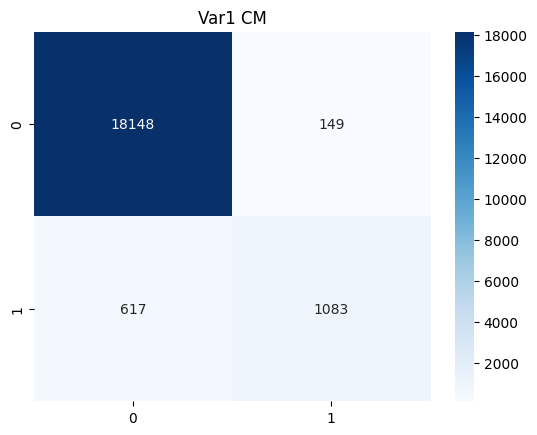

In [25]:
pipe1 = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(random_state=42, max_iter=1000))
])
pipe1.fit(X_train, y_train)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores1 = cross_val_score(pipe1, X_train, y_train, cv=cv, scoring='f1')
print(f"CV F1: {cv_scores1.mean():.4f} ± {cv_scores1.std():.4f}")

y_pred1 = pipe1.predict(X_test)
y_proba1 = pipe1.predict_proba(X_test)[:, 1]
acc1 = accuracy_score(y_test, y_pred1)
prec1 = precision_score(y_test, y_pred1)
rec1 = recall_score(y_test, y_pred1)
f11 = f1_score(y_test, y_pred1)
auc1 = roc_auc_score(y_test, y_proba1)
print(f"Test: Acc {acc1:.4f}, Prec {prec1:.4f}, Rec {rec1:.4f}, F1 {f11:.4f}, AUC {auc1:.4f}")
print(classification_report(y_test, y_pred1))
sns.heatmap(confusion_matrix(y_test, y_pred1), annot=True, fmt='d', cmap='Blues')
plt.title('Var1 CM')
plt.show()

### Variety 2 - LR with Class Weight & GridSearchCV
- Preprocessing - Scaling + balanced weights
- Tuning - GridSearchCV
- Expect improved recall

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Params: {'lr__C': 0.01, 'lr__solver': 'lbfgs'}
CV F1: 0.5711 ± 0.0081
Test: Acc 0.8887, Prec 0.4260, Rec 0.8900, F1 0.5762, AUC 0.9626
              precision    recall  f1-score   support

           0       0.99      0.89      0.94     18297
           1       0.43      0.89      0.58      1700

    accuracy                           0.89     19997
   macro avg       0.71      0.89      0.76     19997
weighted avg       0.94      0.89      0.91     19997



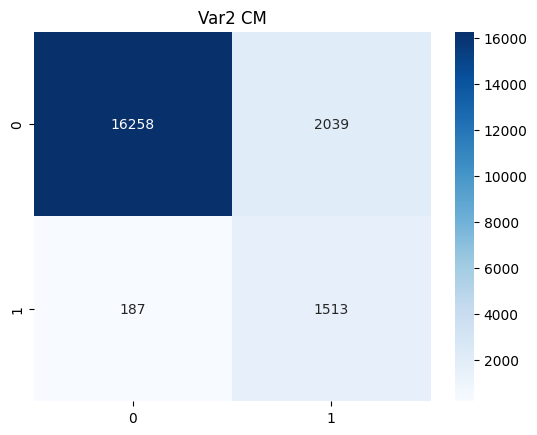

In [26]:
param_grid = {'lr__C': [0.01, 0.1, 1, 10], 'lr__solver': ['liblinear', 'lbfgs']}
pipe2 = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
])
grid2 = GridSearchCV(pipe2, param_grid, cv=cv, scoring='f1', n_jobs=-1, verbose=1)
grid2.fit(X_train, y_train)
print("Best Params:", grid2.best_params_)
cv_scores2 = cross_val_score(grid2.best_estimator_, X_train, y_train, cv=cv, scoring='f1')
print(f"CV F1: {cv_scores2.mean():.4f} ± {cv_scores2.std():.4f}")
y_pred2 = grid2.predict(X_test)
y_proba2 = grid2.predict_proba(X_test)[:, 1]
acc2 = accuracy_score(y_test, y_pred2)
prec2 = precision_score(y_test, y_pred2)
rec2 = recall_score(y_test, y_pred2)
f12 = f1_score(y_test, y_pred2)
auc2 = roc_auc_score(y_test, y_proba2)
print(f"Test: Acc {acc2:.4f}, Prec {prec2:.4f}, Rec {rec2:.4f}, F1 {f12:.4f}, AUC {auc2:.4f}")
print(classification_report(y_test, y_pred2))
sns.heatmap(confusion_matrix(y_test, y_pred2), annot=True, fmt='d', cmap='Blues')
plt.title('Var2 CM')
plt.show()

### Variety 3 - LR with SMOTE & GridSearchCV
- Preprocessing - Scaling + SMOTE
- Tuning - GridSearchCV
- Expect best F1 for imbalance

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Params: {'lr__C': 0.01, 'lr__solver': 'lbfgs'}
CV F1: 0.5717 ± 0.0075
Test: Acc 0.8890, Prec 0.4265, Rec 0.8865, F1 0.5760, AUC 0.9626
              precision    recall  f1-score   support

           0       0.99      0.89      0.94     18297
           1       0.43      0.89      0.58      1700

    accuracy                           0.89     19997
   macro avg       0.71      0.89      0.76     19997
weighted avg       0.94      0.89      0.91     19997



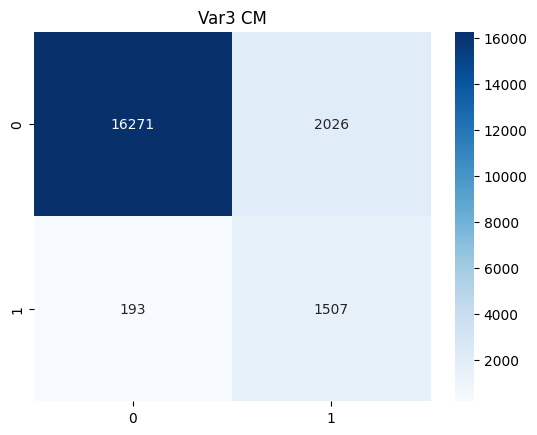

In [27]:
pipe3 = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('lr', LogisticRegression(random_state=42, max_iter=1000))
])
grid3 = GridSearchCV(pipe3, param_grid, cv=cv, scoring='f1', n_jobs=-1, verbose=1)
grid3.fit(X_train, y_train)
print("Best Params:", grid3.best_params_)
cv_scores3 = cross_val_score(grid3.best_estimator_, X_train, y_train, cv=cv, scoring='f1')
print(f"CV F1: {cv_scores3.mean():.4f} ± {cv_scores3.std():.4f}")
y_pred3 = grid3.predict(X_test)
y_proba3 = grid3.predict_proba(X_test)[:, 1]
acc3 = accuracy_score(y_test, y_pred3)
prec3 = precision_score(y_test, y_pred3)
rec3 = recall_score(y_test, y_pred3)
f13 = f1_score(y_test, y_pred3)
auc3 = roc_auc_score(y_test, y_proba3)
print(f"Test: Acc {acc3:.4f}, Prec {prec3:.4f}, Rec {rec3:.4f}, F1 {f13:.4f}, AUC {auc3:.4f}")
print(classification_report(y_test, y_pred3))
sns.heatmap(confusion_matrix(y_test, y_pred3), annot=True, fmt='d', cmap='Blues')
plt.title('Var3 CM')
plt.show()

### Comparison & Conclusion
- Variety 3 outperforms in F1/Recall, best for medical use
- Comparison table/ROC below

,Metric,Var1,Var2,Var3
0,Acc,0.9617,0.8887,0.8890
1,Prec,0.8791,0.4260,0.4265
2,Rec,0.6371,0.8900,0.8865
3,F1,0.7387,0.5762,0.5760
4,AUC,0.9621,0.9626,0.9626


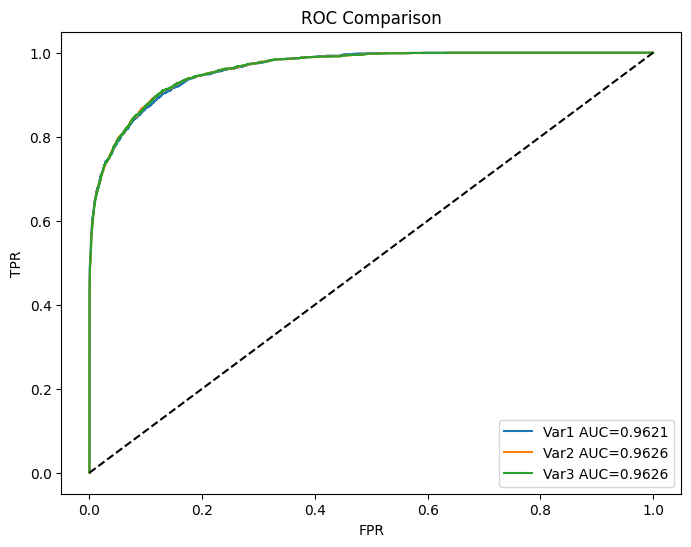

In [28]:
metrics = pd.DataFrame({
    'Metric': ['Acc', 'Prec', 'Rec', 'F1', 'AUC'],
    'Var1': [acc1, prec1, rec1, f11, auc1],
    'Var2': [acc2, prec2, rec2, f12, auc2],
    'Var3': [acc3, prec3, rec3, f13, auc3]
}).round(4)
display(metrics)

fpr1, tpr1, _ = roc_curve(y_test, y_proba1)
fpr2, tpr2, _ = roc_curve(y_test, y_proba2)
fpr3, tpr3, _ = roc_curve(y_test, y_proba3)
plt.figure(figsize=(8,6))
plt.plot(fpr1, tpr1, label=f'Var1 AUC={auc1:.4f}')
plt.plot(fpr2, tpr2, label=f'Var2 AUC={auc2:.4f}')
plt.plot(fpr3, tpr3, label=f'Var3 AUC={auc3:.4f}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC Comparison')
plt.legend()
plt.show()

### Group Comparison

- Challenges - Imbalance required balancing; LR fast but may be outdone by trees on non-linear data